In [51]:
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [52]:
os.listdir()

['data', 'eda.ipynb']

In [53]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
original = pd.read_parquet('data/original.parquet')

In [54]:
original.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [55]:
original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [56]:
original.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [57]:
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [58]:
cat_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium', 'Number of vessels fluro']
for i in cat_cols:
    print('---------------')
    print(train[i].value_counts())
    

---------------
Sex
1    450283
0    179717
Name: count, dtype: int64
---------------
Chest pain type
4    329179
3    197278
2     74941
1     28602
Name: count, dtype: int64
---------------
FBS over 120
0    579608
1     50392
Name: count, dtype: int64
---------------
EKG results
0    320116
2    308562
1      1322
Name: count, dtype: int64
---------------
Exercise angina
0    457553
1    172447
Name: count, dtype: int64
---------------
Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64
---------------
Thallium
3    372286
7    246748
6     10966
Name: count, dtype: int64
---------------
Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64


In [59]:
train['Heart Disease'].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [60]:
train.info()
# 0.44833968253968254 44% Absence
# 0.5516603174603174 55% Presence

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [67]:
df = train.copy()

In [68]:
df['target'] = (df['Heart Disease'] == 'Presence').astype(int)

In [69]:
df = df.drop(columns=['Heart Disease', 'id'])

In [70]:
def col_check(df, column: str):
  vessel_col = column

  prob_table = (
      df.groupby(vessel_col)["target"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "P(Presence)"})
  )

  print(prob_table)

  plt.figure()
  plt.plot(prob_table.index, prob_table["P(Presence)"], marker="o")
  plt.xlabel(column)
  plt.ylabel("P(Heart Disease = Presence)")
  plt.title("Conditional Probability of Heart Disease")
  plt.grid(True)
  plt.show()


In [ ]:
for i in cat_cols:
    col_check(df, i)

In [76]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,target
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873,0.448340
std,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007,0.497324
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,0.000000
75%,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  target                   630000 non-null  int64  
dtypes: f

In [77]:
df.columns

Index(['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
       'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
       'Slope of ST', 'Number of vessels fluro', 'Thallium', 'target'],
      dtype='object')

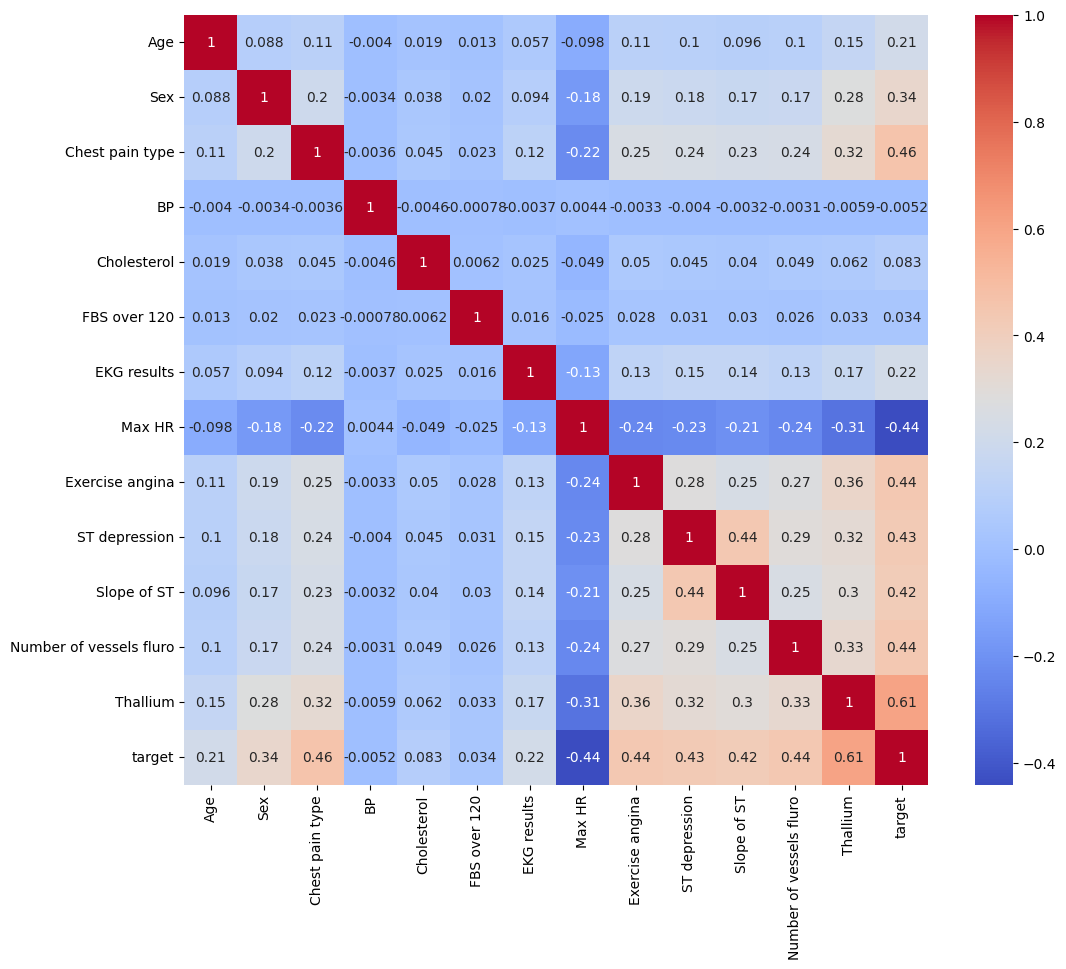

In [75]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.show()

In [ ]:
# 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120',
# 'EKG results', 'Max HR', 'Exercise angina', 'ST depression',
# 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'target'
def new_features(data):
    data['depress x exercise'] = data['ST depression'] * data['Exercise angina']
    data['depress x exercise'] = data['ST depression'] * data['Exercise angina'] * data['Typical']
eda = df.copy()

plt.figure(figsize=(15,15))
sns.heatmap(new_features(eda).corr(), cmap='coolwarm', annot=True, mask = True)
plt.show()

In [162]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import numpy as np

# ----------------------------
# Feature / target
# ----------------------------
X = df.drop(columns=["target"])
y = df["target"]

num_cols = [
    'Thallium', 'Sex', 'Slope of ST', 'Age',
    'Number of vessels fluro', 'Exercise angina',
    'Max HR', 'Chest pain type', 'EKG results',
    'Cholesterol', 'FBS over 120', 'BP',
    'ST depression'
]

X['Thallium_x2'] = X['Thallium'] / X['Slope of ST']
newly_adds = ['Thallium_x2']
# num_cols.extend(newly_adds)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

coefs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Scaling (fit ONLY on train)
    # ----------------------------
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()

    X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_val_scaled[num_cols] = scaler.transform(X_val[num_cols])

    # ----------------------------
    # Model
    # ----------------------------
    log_reg = LogisticRegression(
        max_iter=10000,
        solver="lbfgs"
    )

    log_reg.fit(X_train_scaled[num_cols], y_train)

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = log_reg.predict(X_val_scaled[num_cols])
    y_proba = log_reg.predict_proba(X_val_scaled[num_cols])[:, 1]

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    coefs.append(log_reg.coef_[0])

    print(f"Fold {fold} done")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average coefficients
# ----------------------------
coef_mean = pd.Series(
    np.mean(coefs, axis=0),
    index=num_cols
).sort_values(ascending=False)

print("\nAverage coefficients across folds:")
print(coef_mean)

print("\nAverage odds ratios:")
print(np.exp(coef_mean))


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

CV Results (mean ± std):
ACCURACY  : 0.8831 ± 0.0007
ROC_AUC   : 0.9505 ± 0.0003
PRECISION : 0.8798 ± 0.0006
RECALL    : 0.8563 ± 0.0017
F1        : 0.8679 ± 0.0009

Average coefficients across folds:
Thallium                   0.963492
Chest pain type            0.888216
Number of vessels fluro    0.705441
Exercise angina            0.541903
Sex                        0.483501
ST depression              0.462346
Slope of ST                0.444247
Age                        0.351990
EKG results                0.218882
Cholesterol                0.096726
BP                         0.004105
FBS over 120              -0.010938
Max HR                    -0.837782
dtype: float64

Average odds ratios:
Thallium                   2.620832
Chest pain type            2.430790
Number of vessels fluro    2.024739
Exercise angina            1.719275
Sex                        1.621743
ST depression              1.587795
Slope of ST      

## XGBOSST

In [186]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd

# ----------------------------
# Feature / target
# ----------------------------
X = df.drop(columns=["target"])
y = df["target"]

X_test = test.drop(columns='id')

num_cols = [
    'Thallium', 'Sex', 'Slope of ST', 'Age',
    'Number of vessels fluro', 'Exercise angina',
    'Max HR', 'Chest pain type', 'EKG results',
    'Cholesterol', 'FBS over 120', 'BP',
    'ST depression'
]

# X['Thallium_x2'] = X['Thallium'] / X['Slope of ST']
# X_test['Thallium_x2'] = X_test['Thallium'] / X_test['Slope of ST']
# num_cols.append('Thallium_x2')

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

importances = []

X_res = np.zeros(len(X_test))
X_res_oof = np.zeros(len(X))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Model
    # ----------------------------
    xgb = LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        # objective="binary:logistic",
        objective="binary",
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    xgb = LGBMClassifier(
        objective="binary",
        metric="auc",

        n_estimators=800,
        learning_rate=0.03,

        max_depth=-1,          # let num_leaves control complexity
        num_leaves=48,

        subsample=0.9,
        colsample_bytree=0.9,

        min_child_samples=100,
        reg_alpha=5,
        reg_lambda=5,

        random_state=42,
        n_jobs=-1,
        verbose=-1
    )


    xgb.fit(
        X_train[num_cols],
        y_train,
        eval_set=[(X_val[num_cols], y_val)],
        eval_metric="auc",
        # verbose=False
    )

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = xgb.predict(X_val[num_cols])
    y_proba = xgb.predict_proba(X_val[num_cols])[:, 1]
    X_res += xgb.predict_proba(X_test[num_cols])[:, 1]/5
    X_res_oof += xgb.predict_proba(X[num_cols])[:, 1]/5

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    importances.append(xgb.feature_importances_)
    print(classification_report(y_val, y_pred))
    print(f"Fold {fold} done", f"with ROC-AUC: {metrics['roc_auc'][-1]}")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average feature importance
# ----------------------------
importance_mean = pd.Series(
    np.mean(importances, axis=0),
    index=num_cols
).sort_values(ascending=False)

print("\nAverage feature importances:")
print(importance_mean)

sub_df = pd.DataFrame({'id': test['id'], 'Heart Disease': X_res})


              precision    recall  f1-score   support

           0       0.90      0.90      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

Fold 1 done with ROC-AUC: 0.955548222586477
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.87     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000

Fold 2 done with ROC-AUC: 0.9545607642271182
              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.87      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      

Number of under-predicted positives: 14162
Total number of positives: 282454
Fraction of positives under-predicted: 0.0501
Sample of under-predicted positive cases:


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,target
70,64,0,3,120,211,0,0,162,0,0.0,1,0,7,1
152,64,0,4,130,282,1,2,168,0,0.0,1,0,3,1
206,44,1,4,125,197,0,0,182,0,1.4,1,0,3,1
223,56,1,2,120,260,0,0,154,0,0.0,1,0,3,1
261,48,1,3,180,177,1,2,116,0,0.0,1,0,3,1


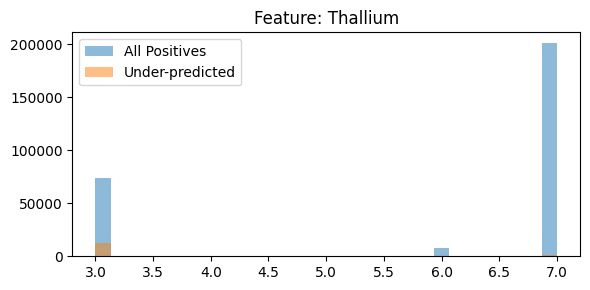

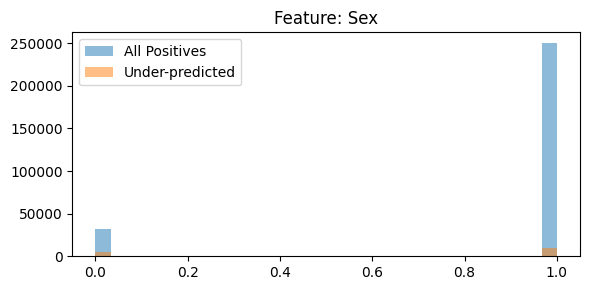

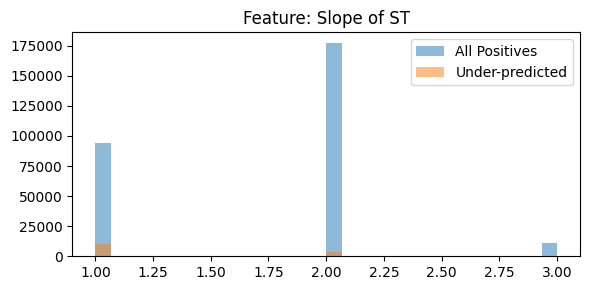

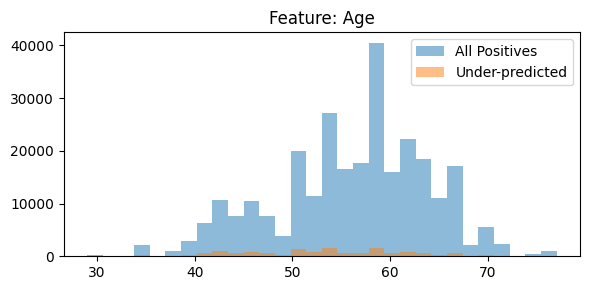

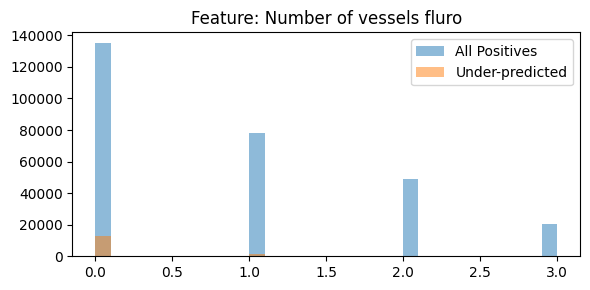

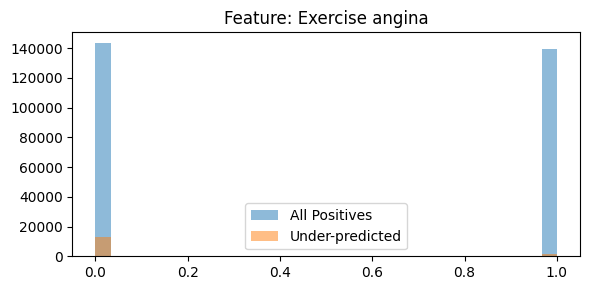

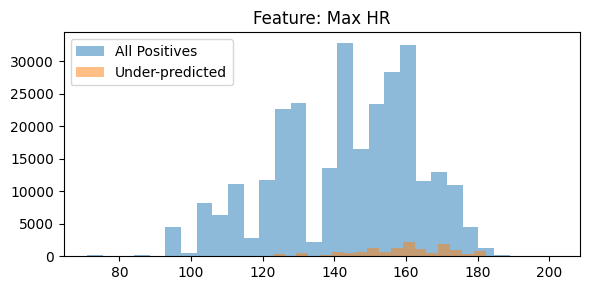

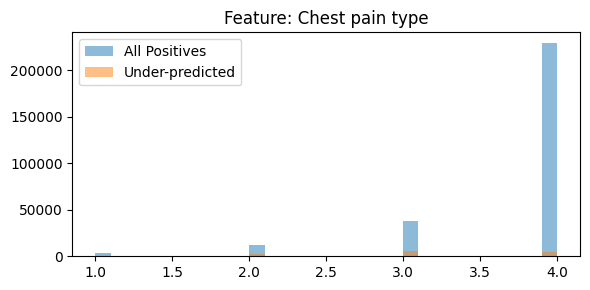

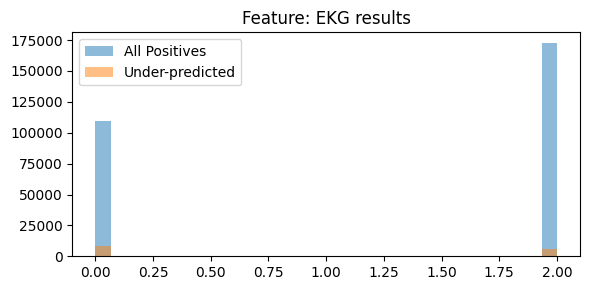

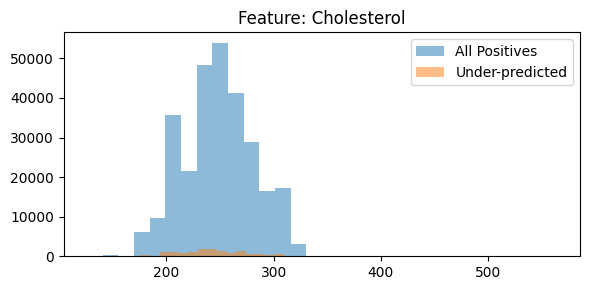

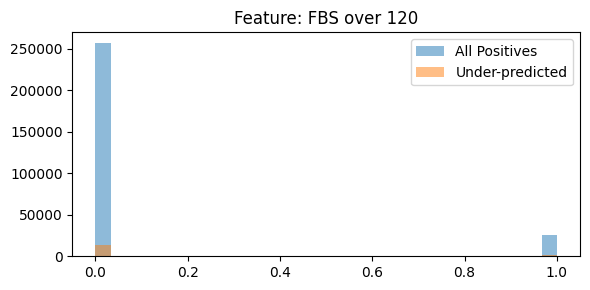

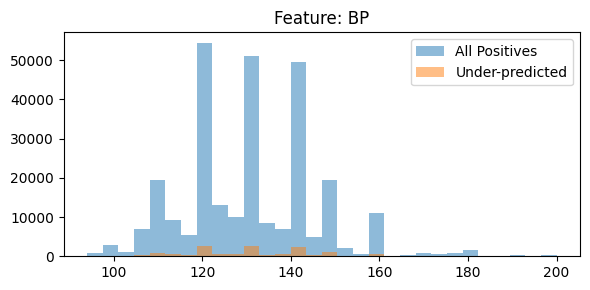

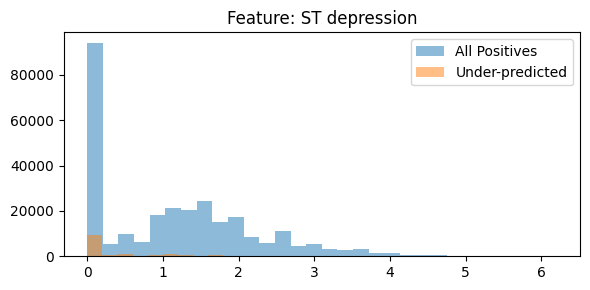

In [187]:
# Analyze under-predictions in X_res_oof (predicted probability < 0.2, but true target == 1)
threshold = 0.2
under_pred_idx = (X_res_oof < threshold) & (y.values == 1)
under_pred_count = under_pred_idx.sum()
total_true_positives = (y.values == 1).sum()

print(f"Number of under-predicted positives: {under_pred_count}")
print(f"Total number of positives: {total_true_positives}")
print(f"Fraction of positives under-predicted: {under_pred_count / total_true_positives:.4f}")

# Show some examples
under_pred_examples = df.loc[under_pred_idx]
print("Sample of under-predicted positive cases:")
display(under_pred_examples.head())

# Compare feature distributions for under-predicted vs. all positives
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(6, 3))
    plt.hist(df.loc[(y.values == 1), col], bins=30, alpha=0.5, label='All Positives')
    plt.hist(under_pred_examples[col], bins=30, alpha=0.5, label='Under-predicted')
    plt.title(f"Feature: {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [184]:
sub_df.to_parquet(r'submission04.parquet', index = False)

In [ ]:
# sub 00 

# CV Results (mean ± std):
# ACCURACY  : 0.8884 ± 0.0008
# ROC_AUC   : 0.9551 ± 0.0004
# PRECISION : 0.8816 ± 0.0004
# RECALL    : 0.8675 ± 0.0020
# F1        : 0.8745 ± 0.0010

# LB        : 0.95323